🟦 🔹 BLOQUE 1: EXTRACCIÓN Y EDA

🟢 1. 📊 Análisis Exploratorio y Modelado de Riesgo

🟢 2. IMPORTS

In [36]:
import pyodbc    
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

🟢 3. EXTRACCIÓN

In [ ]:
conn = pyodbc.connect(
    r"DRIVER={};"
    r"SERVER=;"
    r"DATABASE=;"
    r"Trusted_Connection=;"
)

In [ ]:
query = """
SELECT TOP 100000
    tamano,
    sector,
    departamento,
    nrotrab,
    ventas_prom,
    saldo_miles_soles,
    CASE
        WHEN ventas_prom IS NULL OR ventas_prom = 0 THEN 'SIN INFORMACION'
        WHEN (saldo_miles_soles * 1000.0) / ventas_prom > 1 THEN 'ALTO RIESGO'
        WHEN (saldo_miles_soles * 1000.0) / ventas_prom BETWEEN 0.5 AND 1 THEN 'RIESGO MODERADO'
        ELSE 'BAJO RIESGO'
    END AS semaforo_riesgo
FROM financiamiento_2024_rev_rest
"""


df = pd.read_sql(query, conn)

🟢 4   . CREACIÓN DEL RATIO

In [4]:
df["ratio"] = (df["saldo_miles_soles"] * 1000) / df["ventas_prom"]

In [5]:
df["ratio"] = df["ratio"].replace([np.inf, -np.inf], np.nan)

🟢 5. CALIDAD DE DATOS

In [9]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   tamano             100000 non-null  object 
 1   sector             100000 non-null  object 
 2   departamento       100000 non-null  object 
 3   nrotrab            100000 non-null  int64  
 4   ventas_prom        100000 non-null  float64
 5   saldo_miles_soles  100000 non-null  float64
 6   semaforo_riesgo    100000 non-null  object 
 7   ratio              89973 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 6.1+ MB


In [10]:
df.describe()

,nrotrab,ventas_prom,saldo_miles_soles,ratio
count,100000.000000,1.000000e+05,100000.000000,89973.000000
mean,2.113970,6.947698e+05,120.162132,10.762512
std,7.308809,2.619679e+07,641.838488,291.237321
min,1.000000,0.000000e+00,0.000000,0.000000
25%,1.000000,5.665000e+03,4.380000,0.096205
50%,1.000000,3.347500e+04,25.030000,0.407767
75%,1.000000,2.580150e+05,87.232500,1.805825
max,690.000000,4.630000e+09,60826.240000,52383.067961


In [11]:
(df == 0).sum()

tamano                   0
sector                   0
departamento             0
nrotrab                  0
ventas_prom          10027
saldo_miles_soles      395
semaforo_riesgo          0
ratio                  310
dtype: int64

🟢 6. DISTRIBUCIÓN DEL RATIO

Text(0.5, 1.0, 'Distribución del Ratio')

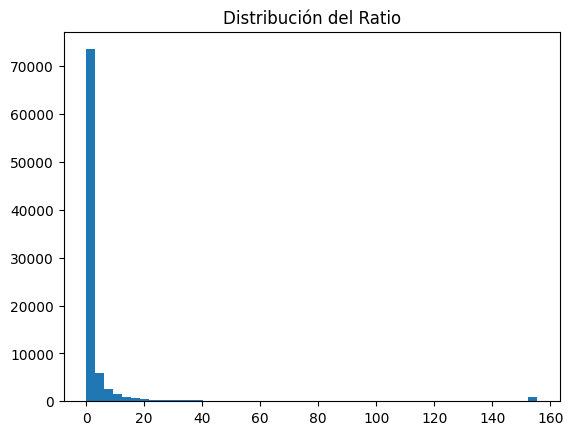

In [28]:
plt.hist(df["ratio"].dropna(), bins=50)
plt.title("Distribución del Ratio")

🟢 7. TRATAMIENTO DE OUTLIERS

In [24]:
df["ratio"] = df["ratio"].clip(upper=df["ratio"].quantile(0.99))

🟢 8. DISTRIBUCIÓN AJUSTADA


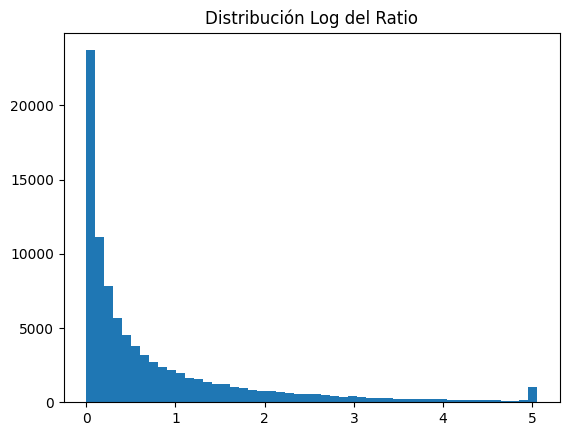

In [27]:
df["log_ratio"] = np.log1p(df["ratio"])

plt.hist(df["log_ratio"].dropna(), bins=50)
plt.title("Distribución Log del Ratio")
plt.show()

🟢 9. TARGET

<Axes: xlabel='semaforo_riesgo', ylabel='count'>

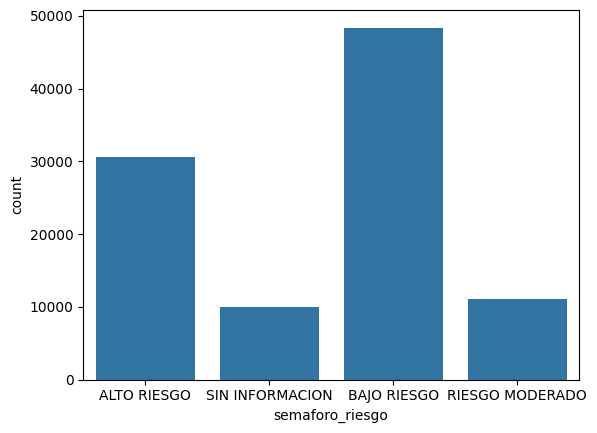

In [29]:
sns.countplot(x="semaforo_riesgo", data=df)

🟢 10. RELACIÓN CLAVE

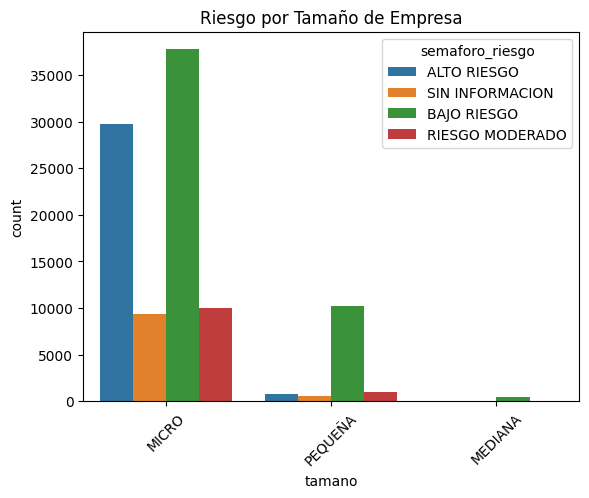

In [25]:
sns.countplot(x="tamano", hue="semaforo_riesgo", data=df)
plt.title("Riesgo por Tamaño de Empresa")
plt.xticks(rotation=45)
plt.show()

## 🔗 Relación entre riesgo y sector

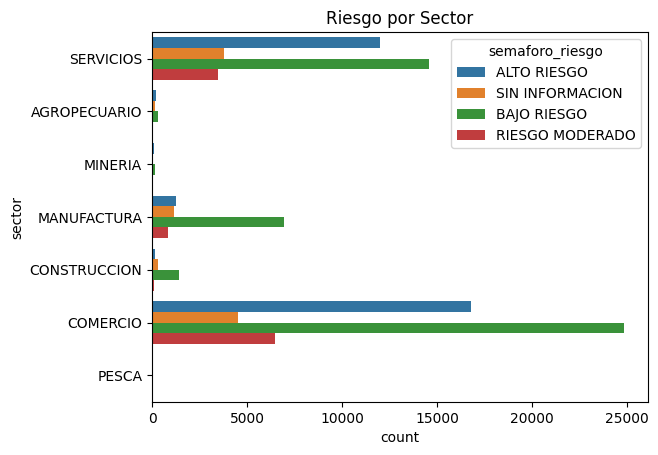

In [30]:
sns.countplot(y="sector", hue="semaforo_riesgo", data=df)
plt.title("Riesgo por Sector")
plt.show()

🟦 🔹 BLOQUE 2: PREPARACIÓN

🟢 11. DATASET FINAL

In [33]:
df_model = df[df["semaforo_riesgo"] != "SIN INFORMACION"]

🟢 12. VARIABLES

In [ ]:
X = df_model[["tamano", "sector", "departamento"]]
y = df_model["semaforo_riesgo"]

🟢 13. TRAIN / TEST

In [63]:
from sklearn.model_selection import train_test_split

X = df_model[["tamano", "sector", "departamento"]]
y = df_model["semaforo_riesgo"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

🟢 14. ENCODING

In [64]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown="ignore")

X_train_enc = encoder.fit_transform(X_train)
X_test_enc = encoder.transform(X_test)

🔴 MODELO 1: SIN BALANCEO

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf_no = RandomForestClassifier(random_state=42)

clf_no.fit(X_train_enc, y_train)

y_pred_no = clf_no.predict(X_test_enc)

🟢 MODELO 2: CON SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train_enc, y_train)

clf_smote = RandomForestClassifier(random_state=42)

clf_smote.fit(X_res, y_res)
y_pred_smote = clf_smote.predict(X_test_enc)

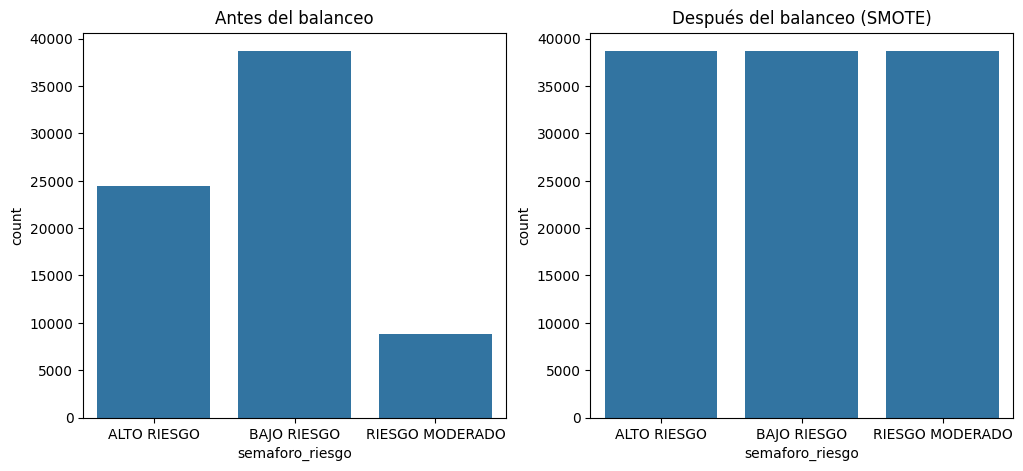

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(x=y_train, ax=ax[0])
ax[0].set_title("Antes del balanceo")

sns.countplot(x=pd.Series(y_res), ax=ax[1])
ax[1].set_title("Después del balanceo (SMOTE)")

plt.show()

🟦 EVALUACIÓN

In [73]:
from sklearn.metrics import classification_report

print("🔴 SIN BALANCEO")
print(classification_report(y_test, y_pred_no))

print("\n🟢 CON SMOTE")
print(classification_report(y_test, y_pred_smote))

🔴 SIN BALANCEO


                 precision    recall  f1-score   support

    ALTO RIESGO       0.46      0.51      0.48      6115
    BAJO RIESGO       0.62      0.71      0.66      9678
RIESGO MODERADO       0.00      0.00      0.00      2202

       accuracy                           0.56     17995
      macro avg       0.36      0.41      0.38     17995
   weighted avg       0.49      0.56      0.52     17995


🟢 CON SMOTE
                 precision    recall  f1-score   support

    ALTO RIESGO       0.44      0.51      0.47      6115
    BAJO RIESGO       0.82      0.36      0.50      9678
RIESGO MODERADO       0.14      0.43      0.21      2202

       accuracy                           0.42     17995
      macro avg       0.47      0.43      0.39     17995
   weighted avg       0.61      0.42      0.45     17995



🟦 MATRIZ DE CONFUSIÓN

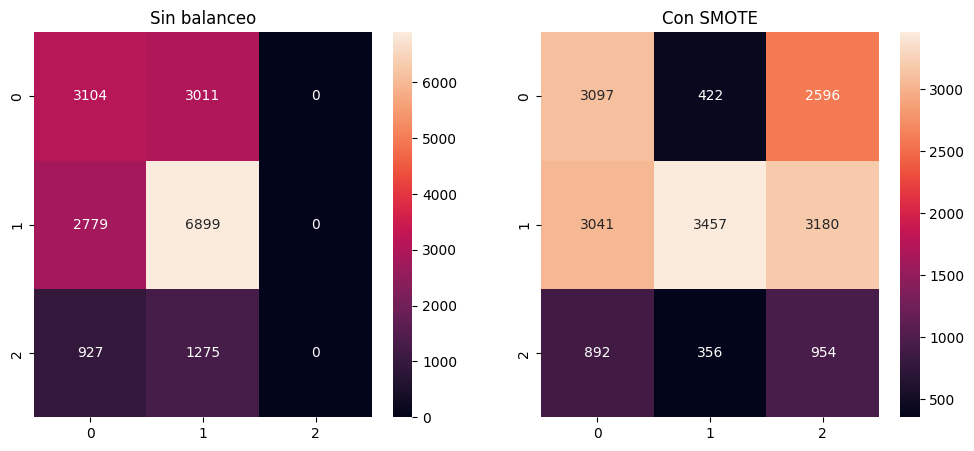

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred_no), annot=True, fmt="d", ax=ax[0])
ax[0].set_title("Sin balanceo")

sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt="d", ax=ax[1])
ax[1].set_title("Con SMOTE")

plt.show()